# MECH 309: Assignment 6, Question 1

_Cagri Arslan_

March 26, 2025

*All work can be found on https://github.com/imported-canuck/MECH-309*

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from Optimize_helpers import * 

# a)

We seek to minimize drag, while maintaining the prescribed volume $V_{req}$. In negative-null form, the problem is posed as:

$$
\min_{l,d} D(l,d) = \frac{1}{2}\rho v^2 C_D(l, d) S(l,d) = f(l, d) \quad \text{subject to} \quad g(l,d) = V(l,d) - V_{req} = 0
$$



The Lagrangian function is defined as:

$$
L(\textbf{x}, \lambda) = f(\textbf{x})+\sum_{j=1}^{m} \lambda_j g_j(\textbf{x})
$$

Here, we have one constraint, hence $m=1$ and the Lagrange function is:

$$
L(\textbf{x}, \lambda) = L(l, d, \lambda) = f(l, d) + \lambda g(l, d) = \frac{1}{2}\rho v^2 C_D(l, d) S(l,d) + \lambda (V(l,d) - V_{req})
$$

So to conclude, the Lagrange function is:

$$
\boxed{L(l, d, \lambda) = \frac{1}{2}\rho v^2 C_D(l, d) S(l,d) + \lambda (V(l,d) - V_{req})}
$$

# b)

The general optimality condition for an equality constrained optimization problem is:

$$
\nabla{L(\textbf{x}, \lambda)} = 
\begin{bmatrix}
    \nabla{_{\textbf{x}}L(\textbf{x}, \lambda)} \\
    \nabla{_{\lambda}L(\textbf{x}, \lambda)}
\end{bmatrix}
=
\textbf{0}
$$

Therefore, for this problem the optimality conditions are:

$$
\nabla{L(l, d, \lambda)} = 
\begin{bmatrix}
    \nabla{_{\lambda}L(l, d, \lambda)} \\
    \nabla{_{l}L(l, d, \lambda)} \\
    \nabla{_{d}L(l, d, \lambda)}
\end{bmatrix}
=
\begin{bmatrix}
    0 \\
    0 \\
    0
\end{bmatrix}
$$

Thus, we have the following requirements:

$$
\boxed{\frac{\partial L}{\partial l} = 0 \quad \frac{\partial L}{\partial d} = 0 \quad \frac{\partial L}{\partial \lambda} = 0}
$$

Since $\frac{\partial L}{\partial \lambda} = g(l, d)$:

$$
\frac{\partial L}{\partial \lambda} = V(l,d) - V_{req} = \frac{\pi}{6}d^2l-2.5 = 0
$$

$\frac{\partial L}{\partial l}$ and $\frac{\partial L}{\partial d}$ are too cumbersome to differentiate by hand, so we will use the finite-difference methods provided in ```Optimize_helpers.py``` to compute these derivatives. However, a small nuance is that ```Optimize_helpers.py``` only gives the numerical derivative of the drag $D(l, d)$, not of the constraint $g(l, d)$ or the entire Lagrange's function $L(l, d, \lambda) = \frac{1}{2}\rho v^2 C_D(l, d) S(l,d) + \lambda (V(l,d) - V_{req})$. This is not an issue, though, since partial derivatives of $L(l,d,\lambda)$ with respect to $l$ and $d$ can be decomposed into the sum of the partial derivative of the drag function (computed numerically) and the partial derivative of the constraint equation (computed analytically). We can express this as:

$$
\frac{\partial L}{\partial l} = \frac{\partial D}{\partial l} + \lambda \frac{\partial g}{\partial l} = 0 \quad \frac{\partial L}{\partial d} = \frac{\partial D}{\partial d} + \lambda \frac{\partial g}{\partial d} = 0 \quad \frac{\partial L}{\partial \lambda} = g(l, d) = 0
$$

Partial derivatives of $D(l, d)$ will be computed numerically, while we calculate the partial derivatives of $g(l, d)$ analytically as such:

$$
\frac{\partial g}{\partial l} = \frac{\pi}{6}d^2 \quad \quad \frac{\partial g}{\partial d} = \frac{\pi}{3}dl
$$

And thus we have:

$$
\boxed{\frac{\partial L}{\partial l} = \frac{\partial D}{\partial l} + \lambda \frac{\pi}{6}d^2 = 0,  \quad \frac{\partial L}{\partial d} = \frac{\partial D}{\partial d} + \lambda \frac{\pi}{3}dl = 0,  \quad \frac{\partial L}{\partial \lambda} = \frac{\pi}{6}d^2l-2.5 = 0}
$$

# c) 

We can simplify the drag model slightly. Recall that:

$$
D(l, d) = \frac{1}{2}\rho v^2 C_D(l, d) S(l,d)
$$

As $\rho$ and $v$ are positive constants, minimizing $D(l, d) = \frac{1}{2}\rho v^2 C_D(l, d) S(l,d)$ is equivalent to minimizing $F(l, d) = C_D(l, d) S(l,d)$. Additionally, we recognize that:

$$
S = \frac{\pi}{2} d^2 \left( 1 + \frac{l}{de}\arcsin(e) \right) \quad \text{and} \quad C_D = C_f \left[ 1 + 1.5 \left(\frac{d}{l}\right)^{3/2} + 7\left(\frac{d}{l}\right)^{3} \right]
$$

We can likewise drop $C_f$ and $\frac{\pi}{2}$. So the final, reduced form of the drag function is:

$$
F^{*}(l, d) = \left( 1 + 1.5 \left(\frac{d}{l}\right)^{3/2} + 7\left(\frac{d}{l}\right)^{3} \right) \left( d^2 + \frac{dl}{e}\arcsin(e) \right) \quad \text{where} \quad e = \sqrt{1-\frac{d^2}{l^2}}
$$

Although running ```main()``` is sufficient to produce the desired output, I re-state the helpers we filled out, to present my code. 

In [2]:
def drag(l, d):
    '''Formula for modified drag function.'''
    if l <= 0 or d <= 0 or d >= l:
        return np.inf

    # Define e^2 = 1 - (d/l)^2
    e2 = 1.0 - (d / l)**2
    if e2 <= 0:
        return np.inf

    e = np.sqrt(e2)

    # F*(l,d) as shown above
    return (
        1.0
        + 1.5 * (d / l)**(3.0 / 2.0)
        + 7.0 * (d / l)**3
    ) * (
        d**2 + (d * l / e) * np.arcsin(e)
    )

def volume(l, d):
    '''Volume of the ellipsoid.'''
    return (np.pi / 6.0) * d**2 * l 

def constraint(l, d):
    ''' Constraint function: volume - 2.5 m^3.'''
    return volume(l, d) - 2.5

def kkt_system(x):
    ''' KKT system for the optimization problem.'''
    l, d, lam = x

    # Avoid invalid region
    if l <= 0 or d <= 0 or d >= l:
        return np.array([1e6, 1e6, 1e6])

    # Using dD_dl, dD_dd and constrain build the kkt system. We compute 
    # gradients of the drag function numerically using finite differences. 
    # We compute gradients of the constraint function analytically.
    eq1 = dD_dl(l, d) + lam * (np.pi / 6.0) * d**2
    eq2 = dD_dd(l, d) + lam * (np.pi / 3.0) * d * l
    eq3 = constraint(l, d)

    return np.array([eq1, eq2, eq3])

In [3]:
def solve_problem(x0=np.array([3.0, 1.0, -100.0]), verbose=False):
    sol = root(kkt_system, x0)

    if not sol.success:
        raise RuntimeError(f"Nonlinear solve failed: {sol.message}")

    l_opt, d_opt, lam_opt = map(float, sol.x)   # converts np.float64 to plain float

    if verbose:
        print("Optimal solution:")
        print(f"  l*      = {l_opt:.6f} m")
        print(f"  d*      = {d_opt:.6f} m")
        print(f"  lambda* = {lam_opt:.6f}")
        print(f"  Reduced objective = {drag(l_opt, d_opt):.6f}")
        print(f"  V(l*,d*) = {volume(l_opt, d_opt):.6f} m^3")

    return l_opt, d_opt, lam_opt

In [4]:
l_opt, d_opt, lam_opt = solve_problem(verbose=False)

print("Optimal solution:")
print(f"  l*      = {l_opt:.6f} m")
print(f"  d*      = {d_opt:.6f} m")
print(f"  lambda* = {lam_opt:.6f}")
print(f"  Reduced objective = {drag(l_opt, d_opt):.6f}")
print(f"  V(l*,d*) = {volume(l_opt, d_opt):.6f} m^3")

Optimal solution:
  l*      = 4.966488 m
  d*      = 0.980496 m
  lambda* = -2.458438
  Reduced objective = 9.219144
  V(l*,d*) = 2.500000 m^3


As seen above, the optimal length $l$ is about $\boxed{4.9665 \; \text{m}}$ and the optimal depth $d$ is about $\boxed{0.9805 \; \text{m}}$. It should be noted that the computed drag value of 9.219 is not actually in units of Newtons, since we divided the drag expression out by dimensional units before optimizing. To recover the true drag value, we must multiply:

$$
D(l^*, d^*) = \frac{1}{2} \rho v^2 C_f \frac{\pi}{2} F^{*}(l^*, d^*) \approx 1254.49 \; \text{N}
$$

Likewise, the $\lambda$ value is also incorrectly scaled. However, being a non-dimensional quantity without a direct physical meaning (albeit an indirect one, relating the sensitivity of the optimal solution to perturbations in the constraint), we do not recover it's "true" value. 

# d)

We plot the optimization contours using the provided function in ``Optimize_helpers.py``. We can visually verify the result, as the computed optimum is indeed the smallest modified Drag value that still lies on the $g(l, d) = 0$ line. 

In [5]:
def plot_optimization_contours(L, Dd, Z, G, l_opt, d_opt,
                               n_levels=20,
                               percentile=85):
    """
    Plot objective contours and constraint curve with optimum.
    """

    plt.figure(figsize=(8, 6))

    # Objective contours
    z_min = np.nanmin(Z)
    z_max = np.nanpercentile(Z, percentile)
    levels = np.linspace(z_min, z_max, n_levels)

    cs = plt.contour(L, Dd, Z, levels=levels)
    plt.clabel(cs, inline=True, fontsize=8)

    # Constraint curve g(l,d)=0
    cc = plt.contour(L, Dd, G, levels=[0.0], linewidths=2)
    plt.clabel(cc, fmt={0.0: r"$g(\ell,d)=0$"})

    # Mark optimum
    plt.plot(l_opt, d_opt, 'ro', markersize=8, label='Optimum')

    plt.xlabel(r'$\ell$ [m]')
    plt.ylabel(r'$d$ [m]')
    plt.title('Objective contours and active constraint')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

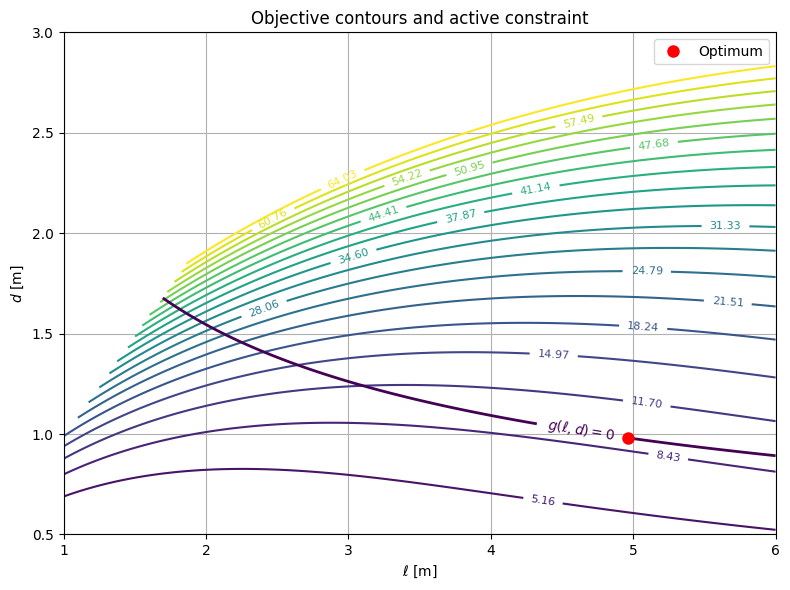

In [6]:
l_vals = np.linspace(1, 6, 200)
d_vals = np.linspace(0.5, 3, 200)
L, Dd = np.meshgrid(l_vals, d_vals)

Z = np.vectorize(drag)(L, Dd).astype(float)
Z[~np.isfinite(Z)] = np.nan

G = constraint(L, Dd).astype(float)
G[Dd >= L] = np.nan

plot_optimization_contours(L, Dd, Z, G, l_opt, d_opt)